In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = np.sqrt(512 * 1e-42) # strain
sigma_inj         = sigma/10.
NSegments         = 50
Fs                = 1024. # Hz
segmentDuration   = 64.0 # s
t0                = 0 # s
TAvg              = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFStoch=1/TAvg
NAvgs = 2 * int(segmentDuration / TAvg) - 1
jobDuration = NSegments * segmentDuration

In [3]:
# Theoretical PSD and sigma for white GWB and white noise

Nfreqs = int((Fs/2) / deltaFStoch)
alpha=3 # white signal
fref=25

w1w2bar, w1w2squaredbar,_,_ = window_factors(NSamplesPerSegment)
PSD_theor = 2*(sigma**2)*deltaT
Pgw_theor = 2*(sigma_inj**2)*deltaT

H_theor = (3*H0**2)/(10*np.pi**2*fref**3) # don't need *(P1.freqs/fref)**(alpha-3) for alpha=3
Y_theor = Pgw_theor/H_theor

var_theor = 1./((segmentDuration)*2*Nfreqs*deltaFStoch * H_theor**2/(PSD_theor**2))
var_theor = w1w2squaredbar / w1w2bar**2 * var_theor
sigma_theor = np.sqrt(var_theor)

print('sigma_theor =', sigma_theor)
print('Y_theor =', Y_theor)

sigma_theor = 0.0002666003559166893
Y_theor = 0.0004894401662160896


In [4]:
# simulate the time series data
noise1=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
noise2=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
inj=sigma_inj*np.random.randn(int(NSamplesPerSegment*NSegments))

times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

d1=TimeSeries(times,noise1 + inj)
d2=TimeSeries(times,noise2 + inj)

In [5]:
# run stochastic pipeline
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,d2,segmentDuration,deltaFStoch,
                                                      fref=fref,alpha=alpha)

stochastic: Done with Interval 1 / 95
	Y     = 1.256250e-04
	sigma = 2.662967e-04
	SNR   = 0.471748
stochastic: Done with Interval 2 / 95
	Y     = 4.914107e-04
	sigma = 2.652533e-04
	SNR   = 1.852609
stochastic: Done with Interval 3 / 95
	Y     = 7.394261e-04
	sigma = 2.650048e-04
	SNR   = 2.790236
stochastic: Done with Interval 4 / 95
	Y     = 6.150379e-04
	sigma = 2.659357e-04
	SNR   = 2.312732
stochastic: Done with Interval 5 / 95
	Y     = 9.927070e-04
	sigma = 2.656573e-04
	SNR   = 3.736795


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_24098/3084087586.py:111: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, ( (3*H0**2)/(10*np.pi**2*freqs**3) ))
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_24098/3084087586.py:120: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II],sigs[II] = calc_Y_sigma_from_Yf_varf(Y_f.data[1:],var_f.data[1:], freqs=freqs[1:], alpha=alpha, fref=fref)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_24098/3084087586.py:121: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data


stochastic: Done with Interval 6 / 95
	Y     = 6.794022e-04
	sigma = 2.649854e-04
	SNR   = 2.563923
stochastic: Done with Interval 7 / 95
	Y     = -8.177785e-05
	sigma = 2.650819e-04
	SNR   = -0.308500
stochastic: Done with Interval 8 / 95
	Y     = 1.431278e-04
	sigma = 2.656102e-04
	SNR   = 0.538864
stochastic: Done with Interval 9 / 95
	Y     = 4.949729e-04
	sigma = 2.656035e-04
	SNR   = 1.863578
stochastic: Done with Interval 10 / 95
	Y     = 2.272251e-04
	sigma = 2.657687e-04
	SNR   = 0.854973
stochastic: Done with Interval 11 / 95
	Y     = 1.508049e-04
	sigma = 2.670787e-04
	SNR   = 0.564646
stochastic: Done with Interval 12 / 95
	Y     = 1.031030e-03
	sigma = 2.664644e-04
	SNR   = 3.869298
stochastic: Done with Interval 13 / 95
	Y     = 8.582353e-04
	sigma = 2.652677e-04
	SNR   = 3.235356
stochastic: Done with Interval 14 / 95
	Y     = -1.657594e-04
	sigma = 2.655613e-04
	SNR   = -0.624185
stochastic: Done with Interval 15 / 95
	Y     = -7.044902e-05
	sigma = 2.669275e-04
	SNR   

In [6]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaFStoch,deltaT)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_24098/2966287306.py:14: RuntimeWarning: invalid value encountered in divide
  Y_f_o = np.sum(Y_fs_odds / var_fs_odds,axis=1) / np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_24098/2966287306.py:15: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1/np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_24098/2966287306.py:17: RuntimeWarning: invalid value encountered in divide
  Y_f_e = np.sum(Y_fs_evens / var_fs_evens,axis=1) / np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_24098/2966287306.py:18: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1/np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_24098/2966287306.py:28: RuntimeWarning: invalid value encountered in subtract
  detC_f = C_f_oo*C_f_ee - C_f_oe**2
/var/folders/h9/8jj76gb51nq2gjkzk76xh3

In [7]:
'''
def reweight(Y_fs, var_fs, alpha1, alpha2):
    
    num_Y_fs = np.shape(Y_fs)[1]
    freqs = Y_fs.freqs
    
    Fw = freqs**(alpha2-alpha1)

    Y_fs_new = np.zeros_like(Y_fs);
    
    for ii in range(num_Y_fs):
        Y_fs_new[:,ii] = Y_fs[:,ii] * Fw
        var_fs_new[:,ii] = var_fs[:,ii]

        Ys_new[ii],sigs_new[ii] = calc_Y_sigma_from_Yf_varf(Y_fs_new[:,1:],var_fs.[:,1:]) 

    return Ys_new, sigs_new
'''

'\ndef reweight(Y_fs, var_fs, alpha1, alpha2):\n    \n    num_Y_fs = np.shape(Y_fs)[1]\n    freqs = Y_fs.freqs\n    \n    Fw = freqs**(alpha2-alpha1)\n\n    Y_fs_new = np.zeros_like(Y_fs);\n    \n    for ii in range(num_Y_fs):\n        Y_fs_new[:,ii] = Y_fs[:,ii] * Fw\n        var_fs_new[:,ii] = var_fs[:,ii]\n\n        Ys_new[ii],sigs_new[ii] = calc_Y_sigma_from_Yf_varf(Y_fs_new[:,1:],var_fs.[:,1:]) \n\n    return Ys_new, sigs_new\n'

In [8]:
# combine point estimates and error bars
Y_opt,sig_opt = postprocessing(Ys,sigs,jobDuration,segmentDuration,deltaF,deltaT,bufferSecs=0)

print('Y_opt =', Y_opt)
print('sig_opt =', sig_opt)

Y_opt = 0.0004825862688893462
sig_opt = 5.99605878551652e-05


20:25 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
20:25 bilby INFO    : Analysis priors:
20:25 bilby INFO    : A=Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
20:25 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
20:25 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
20:25 bilby INFO    : Analysis likelihood noise evidence: -1784.1644920290885
20:25 bilby INFO    : Single likelihood evaluation took 4.400e-05 s
20:25 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None,

4480it [00:04, 798.21it/s, bound:96 nc: 25 ncall:7.6e+04 eff:5.9% logz-ratio=133.71+/-nan dlogz:0.107>0.1]       

20:25 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


4510it [00:06, 695.18it/s, bound:97 nc:  1 ncall:7.7e+04 eff:6.6% logz-ratio=133.81+/-0.11 dlogz:0.000>0.1]

20:25 bilby INFO    : Rejection sampling nested samples to obtain 1400 posterior samples
20:25 bilby INFO    : Sampling time: 0:00:06.485967
20:25 bilby INFO    : Summary of results:
nsamples: 1400
ln_noise_evidence: -1784.164
ln_evidence: -1650.356 +/-  0.134
ln_bayes_factor: 133.808 +/-  0.134



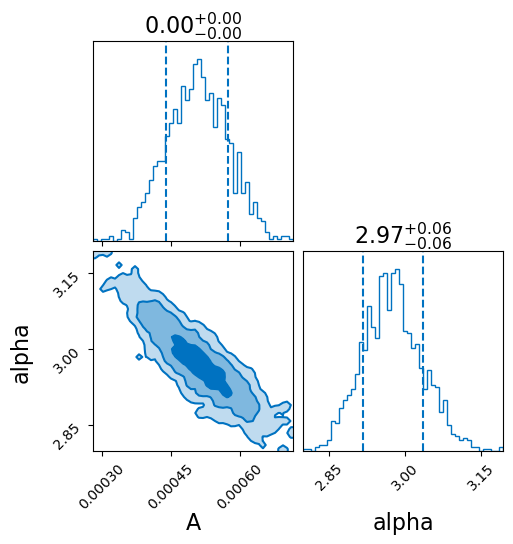

In [9]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-10,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[1:],var_f[1:],freqs[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

In [10]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

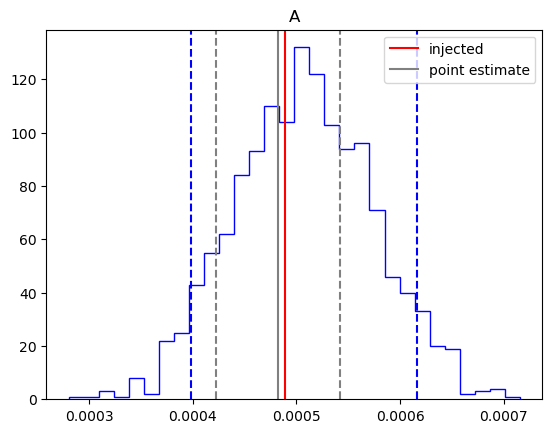

In [11]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(Y_theor,color='red', label='injected')
plt.axvline(Y_opt,color='grey', label='point estimate')
plt.axvline(Y_opt+sig_opt,color='grey', linestyle='--')
plt.axvline(Y_opt-sig_opt,color='grey', linestyle='--')

plt.legend()

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

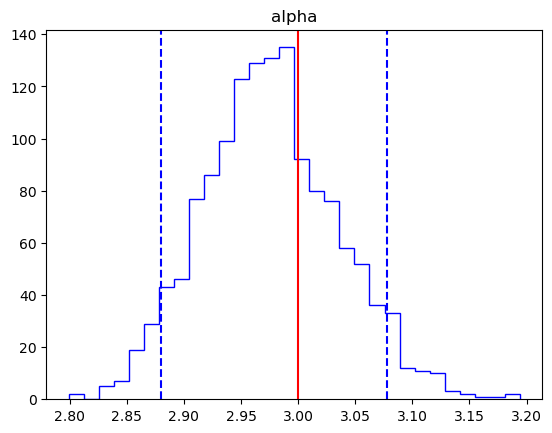

In [12]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(3,color='red')

plt.title('alpha')
plt.xlabel('')